# Week 1 — Data Cleaning & Preparation


## Importing Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Inspecting The Dataset

In [20]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [21]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 9994
Number of columns: 21


In [22]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

# Checking For Missing Values

In [28]:
missing_values = df.isnull().sum()

missing_values

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

# Checking For Any Duplicates

In [29]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


# Checking For Unique Values

## Ship Mode

In [ ]:
df["Ship Mode"].unique()

<StringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str

## Segment

In [31]:
df["Segment"].unique() 

<StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

## Region

In [34]:
df["Region"].unique()

<StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str

## Category

In [35]:
df["Category"].unique()

<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

# Checking Number of Distinct Values

In [36]:
df.nunique()

Row ID           9994
Order ID         5009
Order Date       1237
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              531
State              49
Postal Code       631
Region              4
Product ID       1862
Category            3
Sub-Category       17
Product Name     1850
Sales            5825
Quantity           14
Discount           12
Profit           7287
dtype: int64

## Checking Data Types

In [40]:
# Checkiing Data Types
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

# Convert Date Columns

In [41]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [42]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

# Checking Numerical Values

In [43]:
numeric_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]

df[numeric_columns].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


# Check Negative Sales Values

In [44]:
negative_sales = df[df["Sales"] < 0]

print(f"Negative sales records: {len(negative_sales)}")

Negative sales records: 0


In [45]:
zero_sales = df[df["Sales"] == 0]

print(f"Zero sales records: {len(zero_sales)}")

Zero sales records: 0


## Checking Quantity

In [46]:
invalid_quantity = df[df["Quantity"] <= 0]

print(f"Invalid quantity records: {len(invalid_quantity)}")

Invalid quantity records: 0


## Checking Discount

In [47]:
invalid_discount = df[
    (df["Discount"] < 0) |
    (df["Discount"] > 1)
]

print(f"Invalid discount records: {len(invalid_discount)}")

Invalid discount records: 0


In [ ]:
#Checking available discounts

sorted(df["Discount"].unique())

[np.float64(0.0),
 np.float64(0.1),
 np.float64(0.15),
 np.float64(0.2),
 np.float64(0.3),
 np.float64(0.32),
 np.float64(0.4),
 np.float64(0.45),
 np.float64(0.5),
 np.float64(0.6),
 np.float64(0.7),
 np.float64(0.8)]

## Investigating Negative Profit

In [49]:
negative_profit = df[df["Profit"] < 0]

print(f"Records with negative profit: {len(negative_profit)}")

Records with negative profit: 1871


## Checking Invalid Shipping Dates

In [51]:
invalid_shipping_dates = df[
    df["Ship Date"] < df["Order Date"]
]

print(f"Invalid shipping date records: {len(invalid_shipping_dates)}")

Invalid shipping date records: 0


In [ ]:
# Creating Shipping Dates

df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [53]:
df[[
    "Order Date",
    "Ship Date",
    "Shipping Days"
]].head()

,Order Date,Ship Date,Shipping Days
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


In [57]:
df["Shipping Days"].describe()

count    9994.000000
mean        3.958175
std         1.747567
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

## Checking Shipping Dates

In [58]:
df["Shipping Days"].value_counts().sort_index()

Shipping Days
0     519
1     369
2    1334
3    1005
4    2774
5    2169
6    1203
7     621
Name: count, dtype: int64

## Checking Outliers With Boxplots

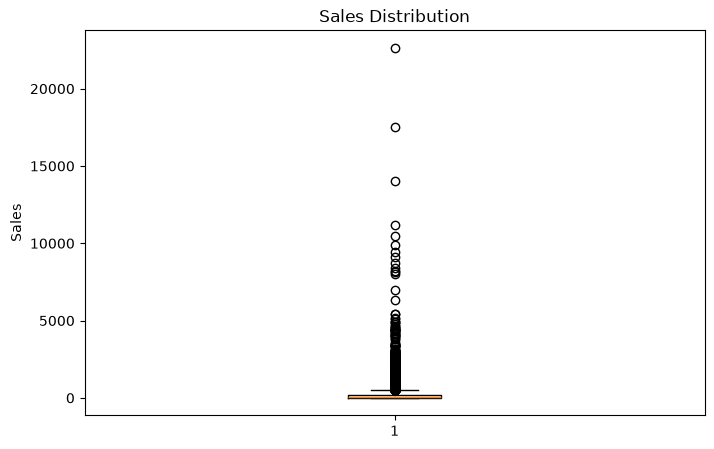

In [ ]:
#Sales Distribution

plt.figure(figsize=(8, 5))

plt.boxplot(df["Sales"])

plt.title("Sales Distribution")
plt.ylabel("Sales")

plt.show()

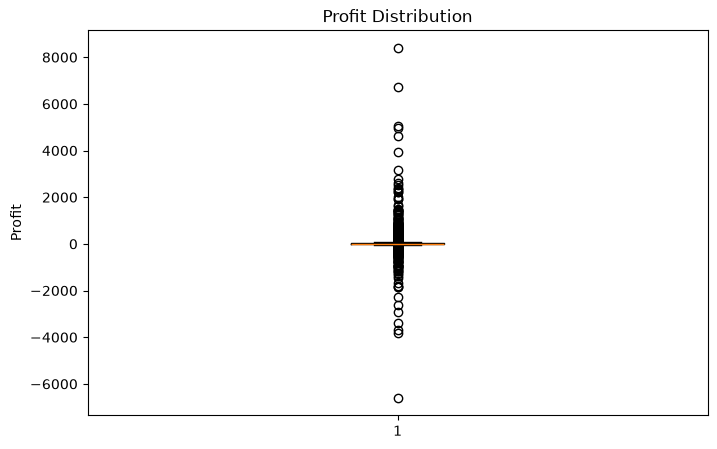

In [ ]:
Profit Distribution

plt.figure(figsize=(8, 5))

plt.boxplot(df["Profit"])

plt.title("Profit Distribution")
plt.ylabel("Profit")

plt.show()

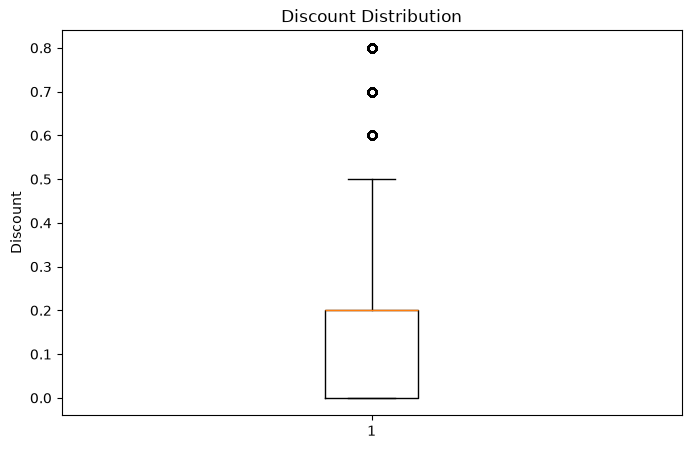

In [63]:
# Discount Distribution

plt.figure(figsize=(8, 5))

plt.boxplot(df["Discount"])

plt.title("Discount Distribution")
plt.ylabel("Discount")

plt.show()

In [ ]:
# Detecting Outliers in Sales

Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

sales_outliers = df[
    (df["Sales"] < lower_bound) |
    (df["Sales"] > upper_bound)
]

print(f"Potential Sales outliers: {len(sales_outliers)}")

Potential Sales outliers: 1167


## Investigating The Largest Sales


In [66]:
df.nlargest(10, "Sales")[
    [
        "Order ID",
        "Customer Name",
        "Product Name",
        "Category",
        "Sales",
        "Profit"
    ]
]

,Order ID,Customer Name,Product Name,Category,Sales,Profit
2697,CA-2014-145317,Sean Miller,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.480,-1811.0784
6826,CA-2016-118689,Tamara Chand,Canon imageCLASS 2200 Advanced Copier,Technology,17499.950,8399.9760
8153,CA-2017-140151,Raymond Buch,Canon imageCLASS 2200 Advanced Copier,Technology,13999.960,6719.9808
2623,CA-2017-127180,Tom Ashbrook,Canon imageCLASS 2200 Advanced Copier,Technology,11199.968,3919.9888
4190,CA-2017-166709,Hunter Lopez,Canon imageCLASS 2200 Advanced Copier,Technology,10499.970,5039.9856
9039,CA-2016-117121,Adrian Barton,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,9892.740,4946.3700
4098,CA-2014-116904,Sanjit Chand,Ibico EPK-21 Electric Binding System,Office Supplies,9449.950,4630.4755
4277,US-2016-107440,Bill Shonely,"3D Systems Cube Printer, 2nd Generation, Magenta",Technology,9099.930,2365.9818
8488,CA-2016-158841,Sanjit Engle,HP Designjet T520 Inkjet Large Format Printer ...,Technology,8749.950,2799.9840
6425,CA-2016-143714,Christopher Conant,Canon imageCLASS 2200 Advanced Copier,Technology,8399.976,1119.9968


## Standardizing Column Names

In [67]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
)

In [68]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit',
       'shipping_days'],
      dtype='str')

## Final Data Quality Check

In [69]:
print("Dataset shape:", df.shape)

print("\nTotal missing values:")
print(df.isnull().sum().sum())

print("\nTotal duplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (9994, 22)

Total missing values:
0

Total duplicate rows:
0

Data types:
row_id                    int64
order_id                    str
order_date       datetime64[us]
ship_date        datetime64[us]
ship_mode                   str
customer_id                 str
customer_name               str
segment                     str
country                     str
city                        str
state                       str
postal_code               int64
region                      str
product_id                  str
category                    str
sub-category                str
product_name                str
sales                   float64
quantity                  int64
discount                float64
profit                  float64
shipping_days             int64
dtype: object


## Final Preview

In [ ]:
# Showing First Five Rows of the Dataset

df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit,shipping_days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7


In [ ]:
# Showing Last Five Rows of the Dataset

df.tail()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit,shipping_days
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028,2
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332,5
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932,5
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200,5
9993,9994,CA-2017-119914,2017-05-04,2017-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480,5


## Saving The Cleaned Dataset

In [73]:
df.to_csv("Superstore_Cleaned.csv", index=False)

print("Cleaned dataset successfully saved.")

Cleaned dataset successfully saved.
